**Load the model from HuggingFace**

In [1]:
from transformers import AutoProcessor, BitsAndBytesConfig, LlavaNextForConditionalGeneration
import torch
from datasets import load_dataset
from pprint import pprint

In [2]:
MODEL_ID = "llava-hf/llava-v1.6-mistral-7b-hf"

**<span style="color:orange">Load the model</span>**

- **<span style="color:yellow">Quantized model: Requires near `8` GB of GPU memory with the configuration provided in the cell below.</span>**
- **<span style="color:yellow">Full model: Requires near `24` GB of GPU for inferencing</span>**

In [3]:
!nvidia-smi

Wed Oct  2 07:18:55 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.183.06             Driver Version: 535.183.06   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off | 00000000:47:00.0 Off |                    0 |
| N/A   27C    P0              51W / 400W |      0MiB / 40960MiB |      0%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

**<span style="color:orange">Function for converting the model output to a nicely formatted JSON</span>**

In [4]:
import os
import json

# Define the base directory for your dataset
dataset_dir = '/home/huuthanhvy.nguyen001/LLMP/LLMP/finetuningDataset1'

# Function to load all JSON files from a given folder
def load_json_files(folder):
    data = {}
    for filename in os.listdir(folder):
        if filename.endswith('.json'):
            file_path = os.path.join(folder, filename)
            with open(file_path, 'r') as f:
                data[filename] = json.load(f)  # Load JSON file and store in dictionary
    return data

# Paths to train, test, and validation folders
train_path = os.path.join(dataset_dir, 'train')
test_path = os.path.join(dataset_dir, 'test')
validation_path = os.path.join(dataset_dir, 'validation')

# Load datasets
train_data = load_json_files(train_path)
test_data = load_json_files(test_path)
validation_data = load_json_files(validation_path)

**<span style="color:orange">Check current directory</span>**

In [5]:
# List the contents of the current working directory
print("Contents of the current directory:")
print(os.listdir())

import os

# Define the directory path you want to move to
dataset_dir = '/home/huuthanhvy.nguyen001/LLMP'

# Check if the directory exists
if os.path.exists(dataset_dir):
    try:
        # Attempt to change the current working directory
        os.chdir(dataset_dir)
        print(f"Successfully changed directory to: {os.getcwd()}")
    except Exception as e:
        print(f"Error: {e}")
else:
    print(f"Directory does not exist: {dataset_dir}")


Contents of the current directory:
['.ipynb_checkpoints', 'fine_tune_llava_1.6_7b_on_cordv2.ipynb', 'test_finetuned_1.6_7b.ipynb', 'Untitled.ipynb']
Successfully changed directory to: /home/huuthanhvy.nguyen001/LLMP


**<span style="color:orange">Load image</span>**

True label: 16


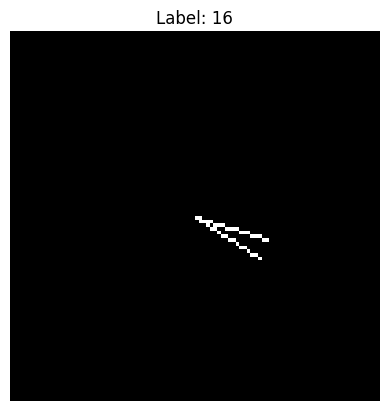

In [6]:
import os
import sys
import LLMP as L

%matplotlib inline
%load_ext autoreload
%autoreload 2
import LLMP as L


import torch
from dotenv import load_dotenv

import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow

# Clear CUDA cache if using GPU
torch.cuda.empty_cache()

# Load environment variables from the .env file3
load_dotenv()

# Assuming `L.GPImage.figure1('direction')` returns an image and label
image, label = L.GPImage.figure1('angle')

# Print the label
print(f"True label: {label}")

# Display the image
plt.imshow(image, cmap='gray')
plt.title(f"Label: {label}")  # Show the label as the title on the plot
plt.axis('off')   # Hide the axes
plt.show()


**<span style="color:orange">Check GPU avalable</span>**

In [7]:
if torch.cuda.is_available():
    print("PyTorch is connected to GPU.")
    print(f"GPU Device Name: {torch.cuda.get_device_name(0)}")
    print(f"Number of GPUs available: {torch.cuda.device_count()}")
    print(f"Current GPU: {torch.cuda.current_device()}")
else:
    print("PyTorch is not connected to GPU.")

PyTorch is connected to GPU.
GPU Device Name: NVIDIA A100-SXM4-40GB
Number of GPUs available: 1
Current GPU: 0


**<span style="color:orange">Load model</span>**

In [8]:
from transformers import BitsAndBytesConfig, LlavaNextForConditionalGeneration, AutoProcessor
from datasets import load_dataset
import torch
import json
from huggingface_hub import notebook_login

MAX_LENGTH = 10
MODEL_ID = "llava-hf/llava-v1.6-mistral-7b-hf"

processor = AutoProcessor.from_pretrained(MODEL_ID)
processor.tokenizer.padding_side = "right" # during training, one always uses padding on the right

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [9]:
!nvidia-smi

Wed Oct  2 07:19:00 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.183.06             Driver Version: 535.183.06   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off | 00000000:47:00.0 Off |                    0 |
| N/A   27C    P0              51W / 400W |      3MiB / 40960MiB |      0%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

**<span style="color:orange">Use QLORA-4bit - convert model to 4bit to save memory</span>**

In [10]:
from transformers import BitsAndBytesConfig, LlavaNextForConditionalGeneration
import torch

USE_LORA = False
USE_QLORA = True

## Load model

# Three options for training, from the lowest precision training to the highest precision training:
# - QLora
# - Standard Lora
# - Full fine-tuning
if USE_QLORA or USE_LORA:
    if USE_QLORA:
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=torch.float16
        )
    model = LlavaNextForConditionalGeneration.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.float16,
        quantization_config=bnb_config,
    )
else:
    # for full fine-tuning, we can speed up the model using Flash Attention
    # only available on certain devices, see https://github.com/Dao-AILab/flash-attention?tab=readme-ov-file#installation-and-features
    model = LlavaNextForConditionalGeneration.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.float16,
        _attn_implementation="flash_attention_2",
    )

`low_cpu_mem_usage` was None, now set to True since model is quantized.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [11]:
!nvidia-smi

Wed Oct  2 07:19:10 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.183.06             Driver Version: 535.183.06   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off | 00000000:47:00.0 Off |                    0 |
| N/A   27C    P0              57W / 400W |   5033MiB / 40960MiB |      0%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

In [12]:
!pip install bitsandbytes

**<span style="color:orange">Parameter-Efficient Fine-Tuning (PEFT)- finetuned a small subset of parameters, and frozen other parameters</span>**

In [13]:
from peft import LoraConfig, prepare_model_for_kbit_training, get_peft_model

def find_all_linear_names(model):
    cls = torch.nn.Linear
    lora_module_names = set()
    multimodal_keywords = ['multi_modal_projector', 'vision_model']
    for name, module in model.named_modules():
        if any(mm_keyword in name for mm_keyword in multimodal_keywords):
            continue
        if isinstance(module, cls):
            names = name.split('.')
            lora_module_names.add(names[0] if len(names) == 1 else names[-1])

    if 'lm_head' in lora_module_names: # needed for 16-bit
        lora_module_names.remove('lm_head')
    return list(lora_module_names)


lora_config = LoraConfig(
    r=8,
    lora_alpha=8,
    lora_dropout=0.1,
    target_modules=find_all_linear_names(model),
    init_lora_weights="gaussian",
)

model = prepare_model_for_kbit_training(model)
model = get_peft_model(model, lora_config)

**<span style="color:orange">Creating a PyTorch dataset class (LlavaDataset) to load and resize images,and return the image and the selected text (ground truth) </span>**

In [14]:
import os
import json
from torch.utils.data import Dataset
import random
from PIL import Image
import torchvision.transforms as transforms
import logging

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

def load_image(image_path):
    """Helper function to load an image and transform it to a tensor."""
    try:
        img = Image.open(image_path).convert("RGB")
        transform = transforms.Compose([
            transforms.Resize((224, 224)),  # Resize image to a fixed size
            transforms.ToTensor()  # Convert the image to a tensor
        ])
        return transform(img)  # Return the transformed image
    except Exception as e:
        print(f"Error loading image: {e}")
        return None

class LlavaDataset(Dataset):
    def __init__(self, data_path: str, dataset_dir: str, sort_json_key: bool = True):
        super().__init__()
        self.dataset_dir = dataset_dir  # Base directory for images
        self.sort_json_key = sort_json_key

        # Load the JSON data
        try:
            with open(data_path, 'r') as f:
                self.data = json.load(f)
        except FileNotFoundError:
            raise FileNotFoundError(f"The file {data_path} was not found.")
        except json.JSONDecodeError:
            raise ValueError(f"The file {data_path} is not a valid JSON file.")

        # Check if the data is non-empty and is a list
        if not isinstance(self.data, list) or len(self.data) == 0:
            raise ValueError("The dataset is empty or not a list")

        self.dataset_length = len(self.data)

        # Prepare tokenized ground truth sequences from conversations
        self.gt_token_sequences = []
        for i, sample in enumerate(self.data):
            if isinstance(sample, dict) and "conversations" in sample:
                conversations = sample["conversations"]
                self.gt_token_sequences.append(
                    [conversation["value"] for conversation in conversations if conversation["from"] == "gpt"]
                )
            else:
                logger.warning(f"Sample at index {i} does not have the expected structure. Skipping.")
                self.gt_token_sequences.append([])

        logger.info(f"Dataset loaded with {self.dataset_length} samples.")

    def __len__(self) -> int:
        return self.dataset_length

    def __getitem__(self, idx: int):
        if idx >= self.dataset_length or idx < 0:
            raise IndexError(f"Index {idx} is out of range for dataset length {self.dataset_length}")

        try:
            sample = self.data[idx]
            if not isinstance(sample, dict):
                raise TypeError(f"Sample at index {idx} is not a dictionary")

            image_filename = sample.get("image")
            if image_filename is None:
                raise KeyError(f"No 'image' key found in sample at index {idx}")

            # Construct the full image path by appending the 'images' subdirectory
            image_path = os.path.join(self.dataset_dir, 'images', image_filename)
            
            # Load the image
            image = load_image(image_path)
            if image is None:
                raise ValueError(f"Failed to load image from {image_path}")

            if not self.gt_token_sequences[idx]:
                raise ValueError(f"No valid conversation found for sample at index {idx}")

            target_sequence = random.choice(self.gt_token_sequences[idx])
            return {"image": image, "target_sequence": target_sequence}

        except Exception as e:
            logger.error(f"Error processing sample at index {idx}: {str(e)}")
            return None


In [15]:
# Set the dataset directory where your images are located
dataset_dir = '/home/huuthanhvy.nguyen001/LLMP/LLMP/finetuningDataset1'
os.chdir(dataset_dir)

# Initialize the dataset objects with the correct arguments
train_dataset = LlavaDataset("./train/dataset.json", dataset_dir, sort_json_key=False)
val_dataset = LlavaDataset("./validation/dataset.json", dataset_dir, sort_json_key=False)

# Example of accessing an item from the dataset
print(train_dataset[0])  # This will print the first sample (image tensor and target sequence)

INFO:__main__:Dataset loaded with 63000 samples.
INFO:__main__:Dataset loaded with 21000 samples.


{'image': tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]]), 'target_sequence': '77'}


**<span style="color:orange">Prepare baches of data for trainning and evaluation</span>**

In [16]:
def train_collate_fn(examples):
    images = []
    texts = []

    for example in examples:
        # Debugging: Print the example if 'target_sequence' is missing
        if "target_sequence" not in example:
            print(f"Missing 'target_sequence' in example: {example}")
            raise KeyError("'target_sequence' not found in the example")

        image = example["image"]
        ground_truth = example["target_sequence"]
        images.append(image)

        # Create the prompt with the ground_truth
        prompt = f"[INST] <image>\nExtract JSON [/INST] {ground_truth}"
        texts.append(prompt)

    batch = processor(
        text=texts,
        images=images,
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )

    labels = batch["input_ids"].clone()
    labels[labels == processor.tokenizer.pad_token_id] = -100
    batch["labels"] = labels

    input_ids = batch["input_ids"]
    attention_mask = batch["attention_mask"]
    pixel_values = batch["pixel_values"]
    image_sizes = batch["image_sizes"]
    labels = batch["labels"]

    return input_ids, attention_mask, pixel_values, image_sizes, labels


def eval_collate_fn(examples):
    images = []
    texts = []
    answers = []

    for example in examples:
        # Access the 'image' and 'target_sequence' directly from the dictionary
        image = example["image"]
        ground_truth = example["target_sequence"]
        images.append(image)

        # Generate the prompt (no ground truth in evaluation)
        prompt = f"[INST] <image>\nExtract JSON [/INST]"
        texts.append(prompt)
        answers.append(ground_truth)

    # Process the images and text using the processor
    batch = processor(
        text=texts,
        images=images,
        return_tensors="pt",
        padding=True
    )

    # Extract the tensors
    input_ids = batch["input_ids"]
    attention_mask = batch["attention_mask"]
    pixel_values = batch["pixel_values"]
    image_sizes = batch["image_sizes"]

    return input_ids, attention_mask, pixel_values, image_sizes, answers


**<span style="color:orange">Handle trainning and validating multimodal LLMs</span>**

In [17]:
import lightning as L
from torch.utils.data import DataLoader
import re
from nltk import edit_distance
import numpy as np


class LlavaModelPLModule(L.LightningModule):
    """
    A PyTorch Lightning module for training and validating a multimodal model that processes images and text.

    Attributes:
        config (dict): Configuration dictionary containing model hyperparameters and settings.
        processor (object): A processor object for handling text and image pre-processing.
        model (torch.nn.Module): The model to be trained and evaluated.

    Methods:
        training_step(batch, batch_idx):
            Executes a single training step, computing the loss and logging it.
        
        validation_step(batch, batch_idx, dataset_idx=0):
            Executes a single validation step, generating predictions, comparing them to ground truth, and logging the normalized edit distance.
        
        configure_optimizers():
            Sets up the optimizer and optionally, learning rate scheduler for the training process.
        
        train_dataloader():
            Returns a DataLoader for the training dataset.
        
        val_dataloader():
            Returns a DataLoader for the validation dataset.
    """
    def __init__(self, config, processor, model):
        super().__init__()
        self.config = config
        self.processor = processor
        self.model = model

        self.batch_size = config.get("batch_size")

    def training_step(self, batch, batch_idx):
        """
        Performs a single step of training.

        Args:
            batch (tuple): A tuple containing input_ids, attention_mask, pixel_values, image_sizes, and labels.
            batch_idx (int): The index of the current batch.

        Returns:
            torch.Tensor: The computed loss for the batch.
        """

        input_ids, attention_mask, pixel_values, image_sizes, labels = batch

        outputs = self.model(input_ids=input_ids,
                            attention_mask=attention_mask,
                            pixel_values=pixel_values,
                            image_sizes=image_sizes,
                            labels=labels
                          )
        loss = outputs.loss

        self.log("train_loss", loss)

        return loss

    def validation_step(self, batch, batch_idx, dataset_idx=0):
        """
        Performs a single step of validation, generating predictions and computing the normalized edit distance.

        Args:
            batch (tuple): A tuple containing input_ids, attention_mask, pixel_values, image_sizes, and answers.
            batch_idx (int): The index of the current batch.
            dataset_idx (int, optional): Index of the dataset in case of multiple datasets. Defaults to 0.

        Returns:
            list: A list of normalized edit distances between predictions and ground truth answers.
        """

        input_ids, attention_mask, pixel_values, image_sizes, answers = batch

        # autoregressively generate token IDs
        generated_ids = self.model.generate(input_ids=input_ids, attention_mask=attention_mask,
                                       pixel_values=pixel_values, image_sizes=image_sizes, max_new_tokens=MAX_LENGTH)
        # turn them back into text, chopping of the prompt
        # important: we don't skip special tokens here, because we want to see them in the output
        predictions = self.processor.batch_decode(generated_ids[:, input_ids.size(1):], skip_special_tokens=True)

        scores = []
        for pred, answer in zip(predictions, answers):
            pred = re.sub(r"(?:(?<=>) | (?=</s_))", "", pred)
            scores.append(edit_distance(pred, answer) / max(len(pred), len(answer)))

            if self.config.get("verbose", False) and len(scores) == 1:
                print(f"Prediction: {pred}")
                print(f"    Answer: {answer}")
                print(f" Normed ED: {scores[0]}")

        self.log("val_edit_distance", np.mean(scores))

        return scores

    def configure_optimizers(self):
        """
        Configures the optimizer for training.

        Returns:
            torch.optim.Optimizer: The optimizer for training.
        """
        # you could also add a learning rate scheduler if you want
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.config.get("lr"))

        return optimizer

    def train_dataloader(self):
        """
        Returns the DataLoader for the training dataset.

        Returns:
            DataLoader: The DataLoader for the training dataset.
        """
        return DataLoader(train_dataset, collate_fn=train_collate_fn, batch_size=self.batch_size, shuffle=True, num_workers=4)

    def val_dataloader(self):
        """
        Returns the DataLoader for the validation dataset.

        Returns:
            DataLoader: The DataLoader for the validation dataset.
        """
        return DataLoader(val_dataset, collate_fn=eval_collate_fn, batch_size=self.batch_size, shuffle=False, num_workers=4)

**<span style="color:orange">Configure trainning parameters</span>**

In [18]:
config = {"max_epochs": 1,
          # "val_check_interval": 0.2, # how many times we want to validate during an epoch
          "check_val_every_n_epoch": 1,
          "gradient_clip_val": 1.0,
          "accumulate_grad_batches": 2,
          "lr": 1e-4,
          "batch_size": 1,
          # "seed":2022,
          "num_nodes": 1,
          "warmup_steps": 50,
          "result_path": "./result",
          "verbose": True,
}

model_module = LlavaModelPLModule(config, processor, model)

**<span style="color:orange">Push your model and processor to the Hugging Face Hub</span>**

In [19]:
from lightning.pytorch.callbacks import Callback
from lightning.pytorch.callbacks.early_stopping import EarlyStopping

from huggingface_hub import HfApi

api = HfApi()

class PushToHubCallback(Callback):
    def on_train_epoch_end(self, trainer, pl_module):
        print(f"Pushing model to the hub, epoch {trainer.current_epoch}")
        pl_module.model.push_to_hub(REPO_ID,
                                    commit_message=f"Training in progress, epoch {trainer.current_epoch}")

    def on_train_end(self, trainer, pl_module):
        print(f"Pushing model to the hub after training")
        pl_module.processor.push_to_hub(REPO_ID,
                                    commit_message=f"Training done")
        pl_module.model.push_to_hub(REPO_ID,
                                    commit_message=f"Training done")

early_stop_callback = EarlyStopping(monitor="val_edit_distance", patience=3, verbose=False, mode="min")

**<span style="color:orange">Start trainning and upload a fined-tuned model on HuggingFace</span>**

In [ ]:
from lightning.pytorch.loggers import WandbLogger

REPO_ID = "raminguyen/fine-tuned-data1"

WANDB_PROJECT = "LLaVaNeXT"
WANDB_NAME = "llava-next-demo-cord"

import torch
torch.cuda.empty_cache()

wandb_logger = WandbLogger(project=WANDB_PROJECT, name=WANDB_NAME)

trainer = L.Trainer(
        accelerator="gpu",
        devices=[0],
        max_epochs=config.get("max_epochs"),
        accumulate_grad_batches=config.get("accumulate_grad_batches"),
        check_val_every_n_epoch=config.get("check_val_every_n_epoch"),
        gradient_clip_val=config.get("gradient_clip_val"),
        precision="16-mixed",
        limit_val_batches=5,
        num_sanity_val_steps=0,
        logger=wandb_logger,
        callbacks=[PushToHubCallback(), early_stop_callback],
        log_every_n_steps=10
)

trainer.fit(model_module)


/home/huuthanhvy.nguyen001/anaconda3/envs/pytorch/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/huuthanhvy.nguyen001/anaconda3/envs/pytorch/li ...
INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: You are using a CUDA device ('NVIDIA A100-SXM4-40GB') that has Tensor Cores. To properly utilize them, you shou

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name  | Type      | Params | Mode 
--------------------------------------------
0 | model | PeftModel | 3.9 B  | train
--------------------------------------------
22.2 M    Trainable params
3.9 B     Non-trainable params
3.9 B     Total params
15,751.029Total estimated model params size (MB)
2962      Modules in train mode
756       Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name  | Type      | Params | Mode 
--------------------------------------------
0 | model | PeftModel | 3.9 B  | train
--------------------------------------------
22.2 M    Trainable params
3.9 B     Non-trainable params
3.9 B     Total params
15,751.029Total estimated model params size (MB)
2962      Modules in train mode
756       Modules in eval mode
/home/huuthanhvy.nguyen001/anaconda3/envs/pytorch/lib/python3.11/site-packages/torch/utils/d

Training: |                                               | 0/? [00:00<?, ?it/s]

It looks like you are trying to rescale already rescaled images. If the input images have pixel values between 0 and 1, set `do_rescale=False` to avoid rescaling them again.
It looks like you are trying to rescale already rescaled images. If the input images have pixel values between 0 and 1, set `do_rescale=False` to avoid rescaling them again.
We detected that you are passing `past_key_values` as a tuple and this is deprecated and will be removed in v4.43. Please use an appropriate `Cache` class (https://huggingface.co/docs/transformers/v4.41.3/en/internal/generation_utils#transformers.Cache)


In [ ]:
!pip install lightning nltk

!conda clean --all -y

In [ ]:
!nvidia-smi

In [ ]:
!kill -9 2525062
!kill -9 2676022
!kill -9 3742188

In [ ]:
!pip install huggingface_hub

In [ ]:
!huggingface-cli login 
